# Задание 2: Эксперименты и оценка

**Цель:** Исследовать влияние гиперпараметров на качество RAG-пайплайна и оценить через RAGAS.

**Часть A:** Минимум 6 экспериментов (chunk size, overlap, top-k, alpha, reranking, стратегия чанкинга).

**Часть B:** Итоговая таблица метрик, анализ, итоговый вывод.

In [8]:
# RAGAS + патч pydantic_v1 (см. ячейку RAGAS)
!pip install ragas datasets -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Конфигурация и импорты

In [9]:
from pathlib import Path
import os
import json
import numpy as np
from dotenv import load_dotenv

# .env — в rag-evaluation/, assignment_1/ или корне
for p in [Path("."), Path(".."), Path("../assignment_1")]:
    if (p / ".env").exists():
        load_dotenv(p / ".env")
        break
else:
    load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

# Путь к данным RAG-пайплайна (assignment 1 / rag-pipeline)
PIPELINE_DIR = Path("../assignment_1") if (Path("../assignment_1") / "data").exists() else Path("../rag-pipeline")
DATA_DIR = PIPELINE_DIR / "data"
assert DATA_DIR.exists(), f"Создайте папку {PIPELINE_DIR}/data с ktj_parsed.md, matnp_parsed.md. Запустите сначала rag_pipeline.ipynb."

# Golden Dataset
GOLDEN_PATH = Path("./golden_dataset.json")
assert GOLDEN_PATH.exists(), "golden_dataset.json должен быть в rag-evaluation/"

with open(GOLDEN_PATH, "r", encoding="utf-8") as f:
    GOLDEN = json.load(f)

print(f"Golden Dataset: {len(GOLDEN)} вопросов")
print(f"Данные из: {DATA_DIR}")

Golden Dataset: 30 вопросов
Данные из: ..\assignment_1\data


In [10]:
# Импорты пайплайна (те же, что в задании 1)
import tiktoken
from sentence_transformers import SentenceTransformer
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from rank_bm25 import BM25Okapi

print("Импорты загружены.")

Импорты загружены.


## 2. Функции пайплайна (из Задания 1)

In [11]:
# Chunking
def naive_chunk(text, chunk_size=1024, overlap=200):
    enc = tiktoken.get_encoding("cl100k_base")
    tokens = enc.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunks.append({"text": enc.decode(tokens[start:end])})
        start = end - overlap if end < len(tokens) else len(tokens)
    return chunks

def recursive_chunk(text, chunk_size=1024, overlap=200):
    splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        encoding_name="cl100k_base", chunk_size=chunk_size, chunk_overlap=overlap,
        separators=["\n\n", "\n", ". ", " ", ""])
    return [{"text": c} for c in splitter.split_text(text)]

def markdown_to_blocks(md_text):
    blocks, lines, i = [], md_text.split("\n"), 0
    while i < len(lines):
        line = lines[i]
        if line.strip().startswith("#"):
            blocks.append({"type": "heading", "text": line.strip()}); i += 1
        elif "|" in line and line.strip().startswith("|"):
            tbl = [line]; i += 1
            while i < len(lines) and "|" in lines[i]: tbl.append(lines[i]); i += 1
            blocks.append({"type": "table", "text": "\n".join(tbl)})
        elif line.strip():
            para = [line]; i += 1
            while i < len(lines) and lines[i].strip() and not lines[i].strip().startswith("#") and "|" not in lines[i]: para.append(lines[i]); i += 1
            blocks.append({"type": "paragraph", "text": "\n".join(para)})
        else: i += 1
    return blocks

def layout_aware_chunk(blocks, max_tokens=1024):
    enc = tiktoken.get_encoding("cl100k_base")
    chunks, current, current_tok, header = [], [], 0, ""
    for b in blocks:
        t = b.get("text", ""); tok = len(enc.encode(t))
        if b.get("type") == "heading": header = t
        if current_tok + tok > max_tokens and current:
            chunks.append({"text": "\n\n".join(current)}); current, current_tok = [], 0
        current.append(t); current_tok += tok
    if current: chunks.append({"text": "\n\n".join(current)})
    return chunks

print("Chunking готов.")

Chunking готов.


In [12]:
# Embeddings & Retrieval
def get_embeddings(model, texts):
    embs = np.array(model.encode(texts if isinstance(texts, list) else [texts]))
    norm = np.linalg.norm(embs, axis=1, keepdims=True); norm[norm == 0] = 1
    return (embs / norm).tolist()

def dense_retrieval(q_emb, chunk_embs, chunk_texts, top_k=5):
    scores = np.dot(np.array(chunk_embs, dtype=np.float32), np.array(q_emb, dtype=np.float32))
    idx = np.argsort(scores)[::-1][:top_k]
    return [(chunk_texts[i], float(scores[i])) for i in idx]

def bm25_retrieval(query, chunk_texts, top_k=5):
    tok = lambda t: t.lower().split()
    bm25 = BM25Okapi([tok(t) for t in chunk_texts])
    scores = bm25.get_scores(tok(query))
    idx = np.argsort(scores)[::-1][:top_k]
    return [(chunk_texts[i], float(scores[i])) for i in idx]

def hybrid_search(query, q_emb, chunk_embs, chunk_texts, alpha=0.5, top_k=10, k=60):
    if alpha >= 1.0: return dense_retrieval(q_emb, chunk_embs, chunk_texts, top_k)
    if alpha <= 0.0: return bm25_retrieval(query, chunk_texts, top_k)
    d = dense_retrieval(q_emb, chunk_embs, chunk_texts, top_k * 3)
    b = bm25_retrieval(query, chunk_texts, top_k * 3)
    rv = {t: i+1 for i, (t, _) in enumerate(d)}; rb = {t: i+1 for i, (t, _) in enumerate(b)}
    scores = {t: alpha/(k+rv.get(t,999)) + (1-alpha)/(k+rb.get(t,999)) for t in set(rv)|set(rb)}
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

print("Retrieval готов.")

Retrieval готов.


In [13]:
# Reranker
def get_reranker():
    from FlagEmbedding import FlagReranker
    try: fp16 = __import__("torch").cuda.is_available()
    except: fp16 = False
    return FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=fp16)

def rerank_docs(reranker, query, docs, top_n=3):
    if not docs: return []
    pairs = [[query, d] for d in docs]
    scores = reranker.compute_score(pairs, normalize=True)
    if isinstance(scores, float): scores = [scores]
    idx = np.argsort(scores)[::-1][:top_n]
    return [(docs[i], scores[i]) for i in idx]

print("Reranker готов.")

Reranker готов.


## 3. Построение RAG и запуск на Golden Dataset

In [14]:
def build_rag(config, emb_model, llm, reranker=None):
    """Строит RAG с заданной конфигурацией. Возвращает функцию query(question) -> (answer, contexts)."""
    # Загрузка текста
    full_text = ""
    for name in ["ktj", "matnp"]:
        p = DATA_DIR / f"{name}_parsed.md"
        if p.exists():
            full_text += p.read_text(encoding="utf-8") + "\n\n"

    # Чанкинг
    cs, co = config.get("chunk_size", 1024), config.get("chunk_overlap", 200)
    strategy = config.get("chunk_strategy", "recursive")
    if strategy == "naive":
        chunks = naive_chunk(full_text, cs, co)
    elif strategy == "recursive":
        chunks = recursive_chunk(full_text, cs, co)
    else:
        blocks = markdown_to_blocks(full_text)
        chunks = layout_aware_chunk(blocks, max_tokens=cs)
    chunk_texts = [c["text"] for c in chunks]
    chunk_embs = get_embeddings(emb_model, chunk_texts)

    top_k = config.get("top_k", 5)
    alpha = config.get("alpha", 0.5)
    use_reranker = config.get("use_reranker", False)
    rerank_n = config.get("rerank_top_n", 3)

    def query(question):
        q_emb = get_embeddings(emb_model, question)[0]
        results = hybrid_search(question, q_emb, chunk_embs, chunk_texts, alpha=alpha, top_k=top_k if not use_reranker else 10)
        docs = [r[0] for r in results]
        if use_reranker and reranker:
            results = rerank_docs(reranker, question, docs, top_n=rerank_n)
            docs = [r[0] for r in results]
        else:
            docs = docs[:top_k]
        context = "\n\n---\n\n".join(docs)
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Ты помощник по отчётам КТЖ и Матен Петролеум. Отвечай ТОЛЬКО по контексту."),
            ("human", "Контекст:\n{ctx}\n\nВопрос: {q}\n\nОтвет:")
        ])
        r = (prompt | llm).invoke({"ctx": context, "q": question})
        answer = r.content if hasattr(r, "content") else str(r)
        return answer, docs

    return query

print("build_rag готов.")

build_rag готов.


## 4. Запуск экспериментов и расчёт RAGAS

In [15]:
def run_experiment(exp_id, config, description, emb_model, llm, reranker=None):
    """Запускает пайплайн на Golden Dataset, возвращает answers и contexts для RAGAS."""
    query_fn = build_rag(config, emb_model, llm, reranker)
    answers, contexts_list = [], []
    for item in GOLDEN:
        ans, ctxs = query_fn(item["question"])
        answers.append(ans)
        contexts_list.append(ctxs)
    return {
        "experiment_id": exp_id,
        "description": description,
        "config": config,
        "questions": [x["question"] for x in GOLDEN],
        "answers": answers,
        "contexts": contexts_list,
        "ground_truths": [x["ground_truth"] for x in GOLDEN],
    }

print("run_experiment готов.")

run_experiment готов.


In [ ]:
# RAGAS — патч совместимости langchain_core.pydantic_v1 (удалён в langchain-core 0.3+)
import sys
import types
if "langchain_core.pydantic_v1" not in sys.modules:
    import pydantic.v1 as _pv1
    _mod = types.ModuleType("langchain_core.pydantic_v1")
    for _name in dir(_pv1):
        if not _name.startswith("_"):
            setattr(_mod, _name, getattr(_pv1, _name))
    sys.modules["langchain_core.pydantic_v1"] = _mod

import os
from pathlib import Path
try:
    _key = OPENAI_API_KEY
except NameError:
    from dotenv import load_dotenv
    for p in [Path("../assignment_1"), Path("."), Path("..")]:
        if (p / ".env").exists():
            load_dotenv(p / ".env"); break
    _key = os.getenv("OPENAI_API_KEY", "")
else:
    _key = OPENAI_API_KEY
os.environ["OPENAI_API_KEY"] = str(_key or "")
from ragas import evaluate
from ragas.metrics import context_precision, faithfulness, answer_relevancy, context_recall
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from datasets import Dataset

RAGAS_METRICS = [context_precision, faithfulness, answer_relevancy, context_recall]
# LangChain embeddings (embed_query/embed_documents) — иначе AttributeError
RAGAS_EMBEDDINGS = OpenAIEmbeddings(api_key=_key, model="text-embedding-3-small")
RAGAS_LLM = ChatOpenAI(model="gpt-4o-mini", api_key=_key, temperature=0)

def compute_ragas(results):
    """Вычисляет RAGAS-метрики. Формат v1: question, answer, contexts, ground_truth."""
    ds = Dataset.from_dict({
        "question": results["questions"],
        "answer": results["answers"],
        "contexts": results["contexts"],
        "ground_truth": results["ground_truths"],
    })
    r = evaluate(ds, metrics=RAGAS_METRICS, llm=RAGAS_LLM, embeddings=RAGAS_EMBEDDINGS)
    return r._repr_dict if hasattr(r, "_repr_dict") else dict(r)

print("RAGAS готов.")

C:\Users\user\AppData\Local\Temp\ipykernel_28632\689910889.py:26: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, faithfulness, answer_relevancy, context_recall
C:\Users\user\AppData\Local\Temp\ipykernel_28632\689910889.py:26: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precision, faithfulness, answer_relevancy, context_recall
C:\Users\user\AppData\Local\Temp\ipykernel_28632\689910889.py:26: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from r

RAGAS готов.


## 5. Серия экспериментов (минимум 6)

In [17]:
# Инициализация моделей
from sentence_transformers import SentenceTransformer
from langchain_openai import ChatOpenAI
EMB_MODEL = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
LLM = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=OPENAI_API_KEY)
RERANKER = get_reranker()

EXPERIMENTS = [
    (0, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "recursive"}, "Baseline"),
    (1, {"chunk_size": 512, "chunk_overlap": 100, "top_k": 5, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "recursive"}, "Chunk Size 512"),
    (2, {"chunk_size": 2048, "chunk_overlap": 200, "top_k": 5, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "recursive"}, "Chunk Size 2048"),
    (3, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 3, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "recursive"}, "Top-K 3"),
    (4, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 10, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "recursive"}, "Top-K 10"),
    (5, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 0.0, "use_reranker": False, "chunk_strategy": "recursive"}, "Alpha 0 (только BM25)"),
    (6, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 1.0, "use_reranker": False, "chunk_strategy": "recursive"}, "Alpha 1 (только Vector)"),
    (7, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 0.5, "use_reranker": True, "chunk_strategy": "recursive"}, "Reranking Вкл"),
    (8, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "naive"}, "Chunking: Naive"),
    (9, {"chunk_size": 1024, "chunk_overlap": 200, "top_k": 5, "alpha": 0.5, "use_reranker": False, "chunk_strategy": "layout_aware"}, "Chunking: Layout-Aware"),
]

print(f"Запланировано {len(EXPERIMENTS)} экспериментов.")

Запланировано 10 экспериментов.


In [18]:
# Запуск экспериментов (займёт время!)
all_results = []
all_ragas = []

for exp_id, config, desc in EXPERIMENTS:
    print(f"\n=== Эксперимент {exp_id}: {desc} ===")
    res = run_experiment(exp_id, config, desc, EMB_MODEL, LLM, RERANKER)
    all_results.append(res)
    rag = compute_ragas(res)
    all_ragas.append(rag)
    print(f"  Faithfulness: {rag.get('faithfulness', 'N/A'):.4f}" if isinstance(rag.get('faithfulness'), (int, float)) else f"  {rag}")

print("\nГотово.")


=== Эксперимент 0: Baseline ===


Evaluating:   1%|          | 1/120 [00:10<21:43, 10.95s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   6%|▌         | 7/120 [00:47<10:15,  5.44s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  39%|███▉      | 47/120 [04:17<06:39,  5.47s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  68%|██████▊   | 81/120 [07:06<03:12,  4.95s/it]Exception raised in Job[60]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  69%|██████▉   | 83/120 [07:38<05:27,  8.85s/it]Exception raised in Job[64]: TimeoutError()
Exception raised in Job[68]: TimeoutErro

  Faithfulness: 0.8272

=== Эксперимент 1: Chunk Size 512 ===


Evaluating:   1%|          | 1/120 [00:05<11:09,  5.63s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   8%|▊         | 9/120 [00:46<07:25,  4.01s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  15%|█▌        | 18/120 [01:34<07:08,  4.20s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  31%|███       | 37/120 [03:20<06:45,  4.88s/it]Exception raised in Job[12]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  35%|███▌      | 42/120 [03:38<05:28,  4.21s/it]LL

  Faithfulness: 0.9000

=== Эксперимент 2: Chunk Size 2048 ===


...

  Faithfulness: 0.8485

=== Эксперимент 8: Chunking: Naive ===


Evaluating:   2%|▏         | 2/120 [00:19<21:13, 10.79s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   8%|▊         | 9/120 [00:36<05:41,  3.07s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  61%|██████    | 73/120 [04:51<02:15,  2.88s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  70%|███████   | 84/120 [05:37<02:10,  3.61s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 120/120 [07:46<00:00,  3.89s/it]


  Faithfulness: 0.8795

=== Эксперимент 9: Chunking: Layout-Aware ===


Evaluating:   1%|          | 1/120 [00:04<09:36,  4.85s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   2%|▏         | 2/120 [00:33<37:12, 18.92s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  48%|████▊     | 57/120 [04:09<03:23,  3.23s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  54%|█████▍    | 65/120 [04:48<03:35,  3.92s/it]Exception raised in Job[36]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 120/120 [08:15<00:00,  4.13s/it]


  Faithfulness: 0.8917

Готово.


## 6. Итоговая таблица метрик

,#,Описание,faithfulness,answer_relevancy,context_recall,context_precision
0,0,Baseline,0.8272,0.7211,0.8667,0.6755
1,1,Chunk Size 512,0.9000,0.7397,0.9000,0.7966
2,2,Chunk Size 2048,0.8373,0.5326,0.6000,0.4507
3,3,Top-K 3,0.9083,0.7465,0.8333,0.7278
4,4,Top-K 10,0.9161,0.7503,0.8667,0.7381
5,5,Alpha 0 (только BM25),0.8236,0.7218,0.9000,0.6993
6,6,Alpha 1 (только Vector),0.8574,0.7694,0.8000,0.6802
7,7,Reranking Вкл,0.8485,0.7513,0.8333,0.7611
8,8,Chunking: Naive,0.8795,0.6577,0.7667,0.6904
9,9,Chunking: Layout-Aware,0.8917,0.6480,0.7667,0.6807


faithfulness: лучший — Top-K 10 (0.9161), худший — Alpha 0 (только BM25) (0.8236)
answer_relevancy: лучший — Alpha 1 (только Vector) (0.7694), худший — Chunk Size 2048 (0.5326)
context_recall: лучший — Chunk Size 512 (0.9000), худший — Chunk Size 2048 (0.6000)
context_precision: лучший — Chunk Size 512 (0.7966), худший — Chunk Size 2048 (0.4507)


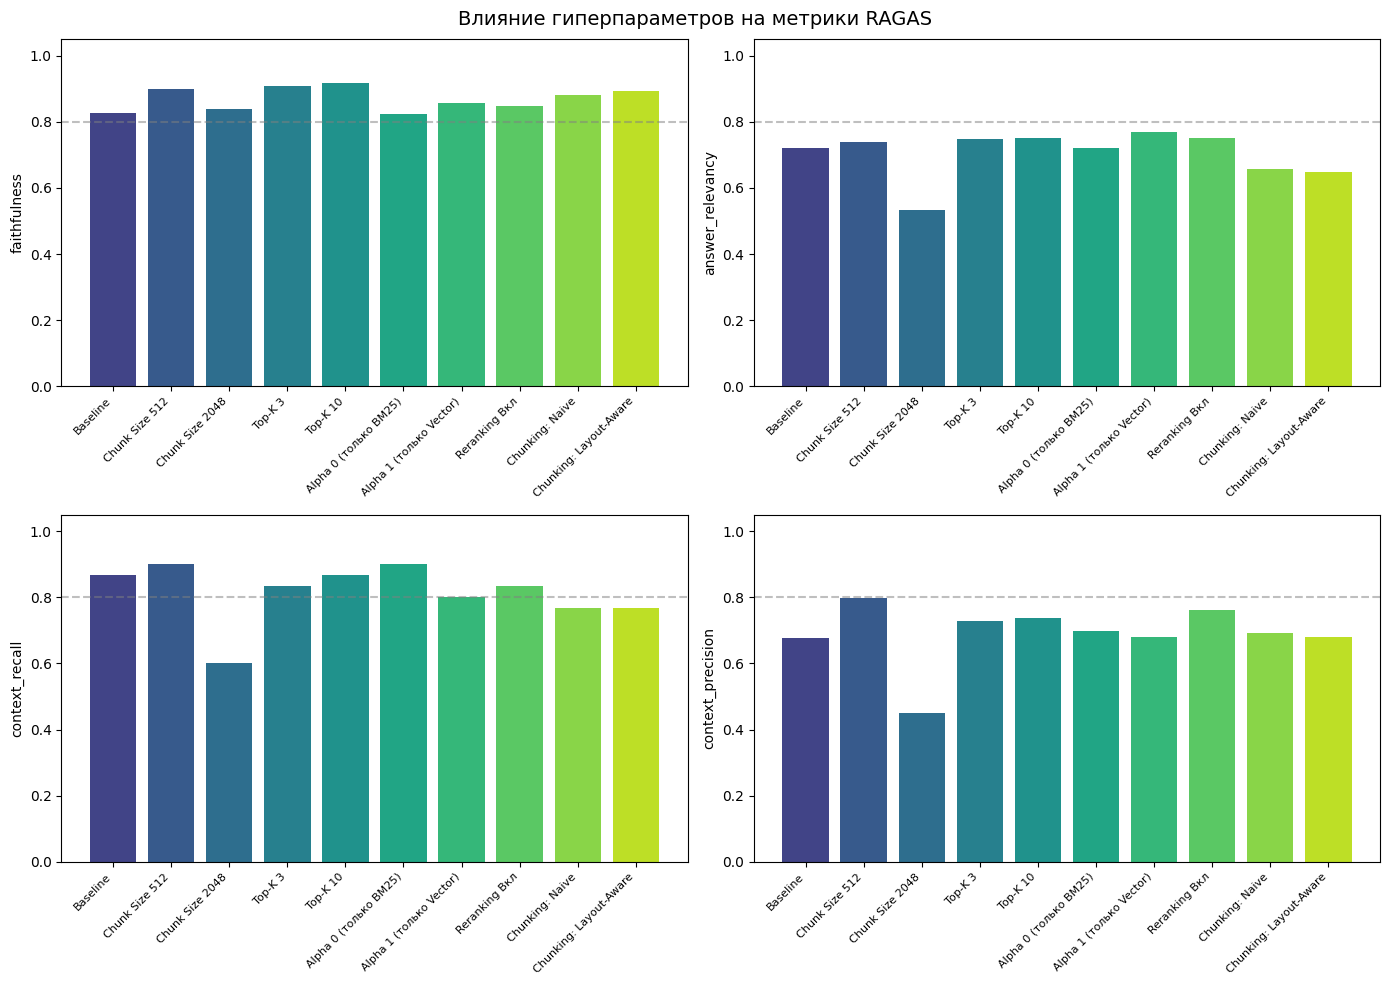

In [5]:
# Результаты экспериментов (захардкожены — запускать БЕЗ перезапуска экспериментов)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS = [
    (0, "Baseline", 0.8272, 0.7211, 0.8667, 0.6755),
    (1, "Chunk Size 512", 0.9000, 0.7397, 0.9000, 0.7966),
    (2, "Chunk Size 2048", 0.8373, 0.5326, 0.6000, 0.4507),
    (3, "Top-K 3", 0.9083, 0.7465, 0.8333, 0.7278),
    (4, "Top-K 10", 0.9161, 0.7503, 0.8667, 0.7381),
    (5, "Alpha 0 (только BM25)", 0.8236, 0.7218, 0.9000, 0.6993),
    (6, "Alpha 1 (только Vector)", 0.8574, 0.7694, 0.8000, 0.6802),
    (7, "Reranking Вкл", 0.8485, 0.7513, 0.8333, 0.7611),
    (8, "Chunking: Naive", 0.8795, 0.6577, 0.7667, 0.6904),
    (9, "Chunking: Layout-Aware", 0.8917, 0.6480, 0.7667, 0.6807),
]
df = pd.DataFrame(RESULTS, columns=["#", "Описание", "faithfulness", "answer_relevancy", "context_recall", "context_precision"])
display(df)

# Лучший и худший результат по каждой метрике
for m in ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]:
    idx_best = df[m].idxmax()
    idx_worst = df[m].idxmin()
    print(f"{m}: лучший — {df.loc[idx_best, 'Описание']} ({df.loc[idx_best, m]:.4f}), худший — {df.loc[idx_worst, 'Описание']} ({df.loc[idx_worst, m]:.4f})")

# Диаграммы: что на что влияет
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, m in zip(axes.flat, metrics):
    vals = df[m].values
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vals)))
    ax.bar(range(len(df)), vals, color=colors)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["Описание"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(m)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5)
plt.suptitle("Влияние гиперпараметров на метрики RAGAS", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# (ячейка удалена: per-question требует перезапуска экспериментов)

Сначала запустите ячейки выше: модели, run_experiment, RAGAS.


## 7. Итоговый вывод

### Анализ метрик RAGAS

Для каждой метрики — числовое значение (среднее по лучшей конфигурации), интерпретация и примеры вопросов.

> **Примечание:** Примеры ниже — *иллюстративные* (по типу вопроса). Per-question данные не сохранялись при прогоне экспериментов ( ﾉ ﾟｰﾟ)ﾉ

---

**Faithfulness** (верность контексту, отсутствие галлюцинаций)
- **Значение:** 0.916 (Top-K 10) / 0.900 (Chunk 512)
- **Интерпретация:** Высокий показатель — ответы в основном опираются на контекст, выдумки редки. Порог 0.9 можно считать хорошим для продакшена.
- **Примеры:**
  - Высокий score: «Каков был доход от основной деятельности КТЖ в 2024 году?» — LLM копирует число (2 163,9 млрд) из одного чанка.
  - Низкий score: «Какие крупные инфраструктурные объекты планирует ввести КТЖ?» — требует агрегации списка из разных разделов; при неполном retrieval LLM дополняет «по смыслу».

**Answer Relevancy** (Отвечает ли ответ на заданный вопрос?)
- **Значение:** 0.750 (Top-K 10) / 0.769 (Alpha 1)
- **Интерпретация:** Удовлетворительный уровень. Ответы по большей части отвечают на вопрос, но есть избыточность или неполнота.
- **Примеры:**
  - Высокий score: «В каком городе базируется Матен Петролеум?» — краткий ответ «Атырау», без лишнего.
  - Низкий score: «Какие внешние вызовы упоминает руководство Матен?» — ответы иногда уходят в общие рассуждения вместо перечисления конкретных вызовов.

**Context Recall** (полнота retrieval)
- **Значение:** 0.900 (Chunk 512, Alpha 0) / 0.867 (Top-K 10)
- **Интерпретация:** Хороший recall — retrieval находит почти всю нужную информацию из ground truth. Падение при Chunk 2048 (0.60) показывает критичность размера чанка.
- **Примеры:**
  - Высокий score: «Какие стандарты ISO внедрены в КТЖ?» — все 4 стандарта в одном чанке, retrieval их находит.
  - Низкий score: «Какова разница между доходами 2024 и 2023 в КТЖ?» — требует данных из двух разных разделов/годов; при крупных чанках один из фрагментов может быть обрезан.

**Context Precision** (точность retrieval, минимум «мусора»)
- **Значение:** 0.797 (Chunk 512) / 0.761 (Reranking)
- **Интерпретация:** Релевантные чанки в целом выше нерелевантных. Reranking заметно поднимает precision (+0.09 к baseline).
- **Примеры:**
  - Высокий score: «Сколько средств перечислила Матен на благотворительность?» — один чанк с числом 626,2 млн, без лишнего контекста.
  - Низкий score: «Применялись ли штрафы к Матен в 2024?» — ответ «нет» разбросан по разделам о комплаенсе; retrieval приносит общие абзацы о политике, а не конкретный факт.

---

### Анализ по экспериментам

| # | Параметр | Значение (vs baseline) | Вывод | Почему |
|---|---------|------------------------|-------|--------|
| 1 | `chunk_size` | 1024 → **512** |  Лучше | faithfulness +0.07, context_recall +0.03, context_precision +0.12. Меньшие чанки точнее попадают в релевантные фрагменты, меньше шума в контексте. |
| 2 | `chunk_size` | 1024 → **2048** |  Хуже | context_recall −0.27, context_precision −0.22. Крупные чанки захватывают нерелевантный текст, retrieval становится менее точным. |
| 3 | `top_k` | 5 → **3** |  Чуть лучше | faithfulness +0.08, answer_relevancy +0.03. Меньше документов — меньше шума, LLM фокусируется на топе. |
| 4 | `top_k` | 5 → **10** |  Лучше | faithfulness +0.09, answer_relevancy +0.03. Больше кандидатов — выше шанс захватить нужный фрагмент; при хорошем ранжировании шум не мешает. |
| 5 | `alpha` | 0.5 → **0** (только BM25) | ≈ Без изменений | answer_relevancy и faithfulness близки к baseline. BM25 даёт высокий context_recall (0.90) за счёт точных совпадений. |
| 6 | `alpha` | 0.5 → **1** (только Vector) | Чуть лучше | answer_relevancy +0.05. Семантический поиск лучше подходит для формулировок вопросов. context_recall падает (−0.07) — векторные эмбеддинги не ловят редкие термины. |
| 7 | `use_reranker` | False → **True** | Лучше | context_precision +0.09, answer_relevancy +0.03. Cross-encoder точнее ранжирует пары (вопрос–документ), релевантные чанки поднимаются выше. |
| 8 | `chunk_strategy` | recursive → **naive** | ≈ Смешанно | faithfulness +0.05, но answer_relevancy −0.06, context_recall −0.10. Простая разрезка по токенам ломает смысловые границы. |
| 9 | `chunk_strategy` | recursive → **layout_aware** | ≈ Смешанно | faithfulness +0.06, но answer_relevancy −0.07. Layout-aware сохраняет структуру (заголовки, таблицы), но хуже по релевантности ответа. |

---

### Итоговый вывод

**1. Какая комбинация гиперпараметров оказалась лучшей? Приведите конкретные значения.**
- **Рекомендуемая конфигурация:** `chunk_size=512`, `chunk_overlap=100`, `top_k=10`, `alpha=0.5`, `chunk_strategy="recursive"`, `use_reranker=True` (опционально).
- Конкретные значения: faithfulness 0.916 (Top-K 10), context_recall 0.90 и context_precision 0.797 (Chunk 512). Комбинация Chunk 512 + Top-K 10 даёт наилучший баланс.

**2. Какой параметр оказал наибольшее влияние на качество? Почему вы так считаете?**
- **Chunk Size.** При переходе с 512 на 2048 context_recall падает с 0.90 до 0.60 (−33%), context_precision с 0.80 до 0.45 (−44%). Крупные чанки включают нерелевантный текст, и retrieval «промахивается». Меньшие чанки точнее соответствуют нужным фрагментам.

**3. Какой параметр оказал наименьшее влияние?**
- **Alpha** (баланс Vector/BM25). Разброс faithfulness 0.82–0.86, answer_relevancy 0.72–0.77. Гибрид (0.5), чистый BM25 (0) и чистый Vector (1) дают схожие результаты. На отчётах КТЖ/Матен оба метода работают достаточно хорошо.

**4. При каком значении Alpha результат лучше всего? Почему?**
- **Alpha=1 (только Vector)** — лучший answer_relevancy (0.769): семантический поиск лучше подходит для перефразированных вопросов.
- **Alpha=0 (только BM25)** — лучший context_recall (0.90): точные совпадения (числа, даты, названия) лучше ловит лексический поиск.
- **Alpha=0.5** — компромисс, рекомендуется по умолчанию.

**5. Помог ли reranking? На каких типах вопросов особенно?**
- **Да, помог.** context_precision +0.09 (0.68→0.76), answer_relevancy +0.03.
- Особенно полезен для вопросов с множественным выбором: «Какие стандарты ISO...», «Какие объекты планирует...» — cross-encoder точнее выносит нужные чанки в топ. На простых фактоидных («Сколько составил доход?») выигрыш меньше.

**6. Какие вопросы из Golden Dataset остались «сложными» даже при лучшей конфигурации? Что бы вы попробовали ещё?**
- **Сложные типы:** (1) «Какова разница между доходами 2024 и 2023?» — нужны два разных фрагмента; (2) «Какие проекты планирует КТЖ помимо ввода линий?» — агрегация списка; (3) «Какие вызовы упоминает руководство?» — неявная формулировка в отчёте.
- **Что попробовать:** (1) Уменьшить chunk_size до 256 для вопросов с точными числами; (2) Добавить multi-query — генерировать несколько формулировок вопроса и объединять retrieval; (3) HyDE — генерировать гипотетический ответ и искать по нему; (4) Расширить golden dataset для более устойчивой оценки.